# 13.To evaluate CNN model performance using accuracy and loss metrics.

### Aim

To evaluate the performance of a Convolutional Neural Network (CNN) model using accuracy and loss metrics and visualize the training and validation performance.

## Introduction

Evaluating the performance of a CNN model is an important step in Deep Learning. After training a model, we need to determine how accurately it performs on unseen data.

Two commonly used metrics are:

- Accuracy
- Loss

Accuracy measures how many predictions are correct, while loss measures the difference between the predicted output and the actual output.

## Accuracy

Accuracy is the ratio of correctly classified samples to the total number of samples.

### Formula

Accuracy = Correct Predictions / Total Predictions

A higher accuracy indicates that the model is making more correct predictions.

## Loss

Loss is a numerical value that represents the difference between the predicted output and the actual output.

A lower loss generally indicates better model performance.

For multiclass image classification, Sparse Categorical Crossentropy is commonly used as the loss function.

## Training and Validation Metrics

During training, the model's performance can be monitored using:

- Training Accuracy
- Validation Accuracy
- Training Loss
- Validation Loss

Training metrics represent the performance on training data, while validation metrics represent the performance on data that was not used for updating the model weights.

Comparing training and validation metrics can help identify problems such as overfitting and underfitting.

## Algorithm

1. Import the required libraries.
2. Load the CIFAR-10 dataset.
3. Normalize the image data.
4. Build a CNN model.
5. Compile the model using an optimizer, loss function, and accuracy metric.
6. Train the CNN model.
7. Store training and validation accuracy and loss.
8. Evaluate the model on test data.
9. Plot accuracy curves.
10. Plot loss curves.
11. Analyze the model performance.

In [2]:
#Import Libraries
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, layers, models

In [3]:
# Load CIFAR-10 dataset

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

Training Images : (50000, 32, 32, 3)
Testing Images  : (10000, 32, 32, 3)


In [4]:
# Normalize pixel values

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Normalization Completed")

Normalization Completed


In [5]:
#Build CNN Model
model = models.Sequential([
    
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    
    layers.Dense(
        128,
        activation='relu'
    ),
    
    layers.Dense(
        10,
        activation='softmax'
    )
])

model.summary()

C:\Users\Smit\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [7]:
#Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.3561 - loss: 1.7627 - val_accuracy: 0.5446 - val_loss: 1.2959
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.5800 - loss: 1.1987 - val_accuracy: 0.6078 - val_loss: 1.1200
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.6427 - loss: 1.0168 - val_accuracy: 0.6422 - val_loss: 1.0336
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.6823 - loss: 0.9177 - val_accuracy: 0.6668 - val_loss: 0.9746
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.7079 - loss: 0.8380 - val_accuracy: 0.6668 - val_loss: 0.9651
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.7349 - loss: 0.7645 - val_accuracy: 0.6835 - val_loss: 0.9364
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.7600 - loss: 0.6916 - val_accuracy: 0.6967 - val_loss: 0.9005
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.7824 - loss: 0.6245 - 

In [8]:
#Display Training History
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [9]:
#Evaluate Test Data
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6909 - loss: 0.9658
Test Loss     : 0.9607020616531372
Test Accuracy : 0.6923999786376953


## Accuracy Curve

The accuracy curve shows how the training and validation accuracy change as the number of epochs increases.

If both training and validation accuracy increase and remain close to each other, the model is generally learning effectively.

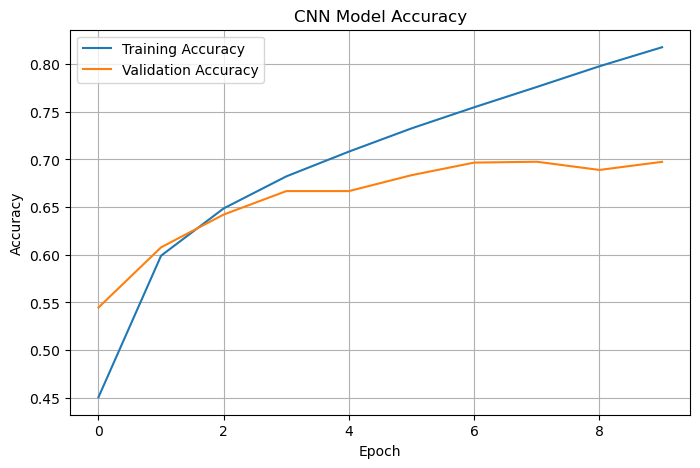

In [10]:
#Plot Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## Loss Curve

The loss curve shows how the training and validation loss change during training.

A decreasing training loss generally indicates that the model is learning from the training data.

If validation loss starts increasing while training loss continues decreasing, it may indicate overfitting.

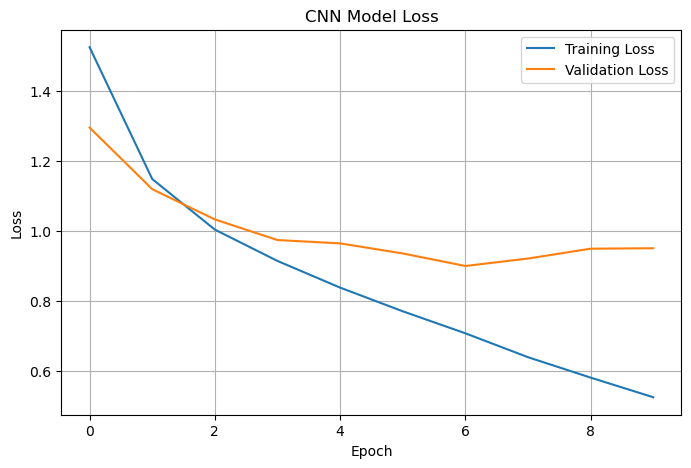

In [11]:
#Plot Loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## Observation

- Training accuracy generally increases as the model learns.
- Training loss generally decreases during training.
- Validation accuracy indicates how well the model performs on unseen validation data.
- Validation loss helps identify whether the model is overfitting.
- Accuracy and loss curves provide a visual understanding of CNN training performance.

## Result

The performance of the CNN model was successfully evaluated using accuracy and loss metrics. Training and validation curves were plotted to analyze the learning behavior of the model, and the final performance was evaluated using the test dataset.